# CT Preprocessing Pipeline — From Raw DICOM to Model-Ready Tensors

This notebook builds and sanity-checks the CT preprocessing pipeline used to turn raw
NSCLC-Radiomics DICOM series into model-ready NumPy tensors for the Vision Agent.

**Decisions, based on the TCIA imaging EDA (`02_tcia_imaging_eda.ipynb`):**

- **Source data**: NSCLC-Radiomics, 422 patients with matched clinical data and CT + RTSTRUCT.
- **Native geometry**: ~0.977 x 0.977 x 3.0 mm voxel spacing (512x512xN volumes), consistent
  across the cohort.
- **Target spacing**: `(1.0, 1.0, 3.0)` mm — rounds the in-plane spacing to a clean 1mm grid
  while leaving the through-plane (z) spacing untouched, since 3.0mm is already the native
  slice thickness for almost every patient. This minimises z-axis interpolation artefacts
  while standardising the in-plane resolution.
- **HU window**: clip to `[-1000, 400]` — covers air/lung parenchyma through soft tissue and
  bone, which spans the tumour and surrounding anatomy while discarding extreme metal/artifact
  outliers.
- **Normalisation**: per-volume z-score, applied *after* clipping, so every CT volume fed to
  the model has comparable intensity statistics regardless of scanner/acquisition differences.
- **Patch size** `(128, 128, 64)` is recorded for future use (training/inference tiling) but is
  not implemented in this notebook.

The pipeline itself lives in `scripts/preprocessing/`:
- `dicom_loader.py` — `load_ct_series`, `load_rtstruct_mask`
- `preprocess.py` — `resample_to_spacing`, `clip_and_normalise`, `preprocess_patient`
- `batch_preprocess.py` — CLI for running the pipeline over many patients

Below we walk through each step on a single patient (`LUNG1-001`), then run the full pipeline
on an 8-patient sanity sample identified during the EDA.

In [1]:
import sys
sys.path.append('../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import SimpleITK as sitk
import pydicom
from tqdm.auto import tqdm
from IPython.display import display

from scripts.preprocessing.dicom_loader import load_ct_series, load_rtstruct_mask
from scripts.preprocessing.preprocess import resample_to_spacing, clip_and_normalise, preprocess_patient

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RAW_DIR = Path("../../data/raw/NSCLC-Radiomics")
PROCESSED_DIR = Path("../../data/processed/radiomics")

print(f"RAW_DIR exists: {RAW_DIR.exists()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")

RAW_DIR exists: True
PROCESSED_DIR: /Users/hp/Sem 2 CAs/Practicum/week4/data/processed/radiomics


In [2]:
patient_id = "LUNG1-001"
patient_dir = RAW_DIR / patient_id

ct_image = load_ct_series(patient_dir)
ct_array = sitk.GetArrayFromImage(ct_image)  # shape (Z, Y, X)
spacing = ct_image.GetSpacing()  # (X, Y, Z)

mask_array = load_rtstruct_mask(patient_dir, ct_image)  # shape (Z, Y, X)

voxel_volume_cm3 = (spacing[0] * spacing[1] * spacing[2]) / 1000.0
tumour_volume_cm3 = mask_array.sum() * voxel_volume_cm3

print(f"Patient: {patient_id}")
print(f"CT array shape (Z, Y, X): {ct_array.shape}")
print(f"CT spacing (X, Y, Z) mm:  {spacing}")
print(f"CT intensity range (HU): [{ct_array.min()}, {ct_array.max()}]")
print()
print(f"Mask shape (Z, Y, X):        {mask_array.shape}")
print(f"Mask foreground voxel count: {mask_array.sum()}")
print(f"Tumour volume:               {tumour_volume_cm3:.2f} cm^3")

Patient: LUNG1-001
CT array shape (Z, Y, X): (134, 512, 512)
CT spacing (X, Y, Z) mm:  (0.9765625, 0.9765625, 3.0)
CT intensity range (HU): [-1024, 3034]

Mask shape (Z, Y, X):        (134, 512, 512)
Mask foreground voxel count: 56637
Tumour volume:               162.04 cm^3


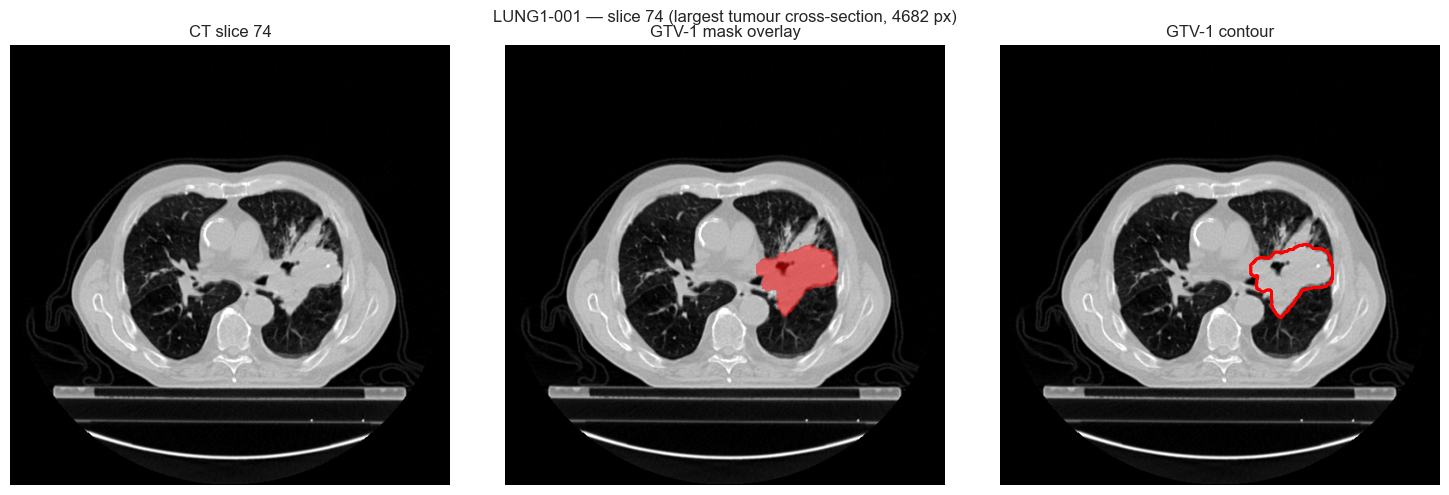

In [3]:
# Pick the slice with the largest tumour cross-section
slice_idx = int(np.argmax(mask_array.sum(axis=(1, 2))))
ct_slice = ct_array[slice_idx]
mask_slice = mask_array[slice_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title(f"CT slice {slice_idx}")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(mask_slice == 0, mask_slice), cmap="autumn", alpha=0.5)
axes[1].set_title("GTV-1 mask overlay")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[2].contour(mask_slice, colors="red", linewidths=1.5)
axes[2].set_title("GTV-1 contour")
axes[2].axis("off")

fig.suptitle(f"{patient_id} — slice {slice_idx} (largest tumour cross-section, "
              f"{int(mask_slice.sum())} px)")
plt.tight_layout()
plt.show()

## Resampling

Resample the CT (B-spline) and mask (nearest-neighbour) from native spacing to the target `(1.0, 1.0, 3.0)` mm grid.

In [4]:
TARGET_SPACING = (1.0, 1.0, 3.0)

ct_resampled = resample_to_spacing(ct_image, target_spacing=TARGET_SPACING, interpolator=sitk.sitkBSpline)

mask_image = sitk.GetImageFromArray(mask_array)
mask_image.CopyInformation(ct_image)
mask_resampled = resample_to_spacing(mask_image, target_spacing=TARGET_SPACING, interpolator=sitk.sitkNearestNeighbor)

ct_resampled_array = sitk.GetArrayFromImage(ct_resampled)
mask_resampled_array = sitk.GetArrayFromImage(mask_resampled)

print("CT volume:")
print(f"  Original shape (Z,Y,X):  {ct_array.shape}, spacing (X,Y,Z): {ct_image.GetSpacing()}")
print(f"  Resampled shape (Z,Y,X): {ct_resampled_array.shape}, spacing (X,Y,Z): {ct_resampled.GetSpacing()}")
print()
print("Mask volume:")
print(f"  Original shape (Z,Y,X):  {mask_array.shape}")
print(f"  Resampled shape (Z,Y,X): {mask_resampled_array.shape}")
print(f"  Resampled mask unique values: {np.unique(mask_resampled_array)}")
print()

voxel_vol_before = np.prod(ct_image.GetSpacing()) / 1000.0
voxel_vol_after = np.prod(ct_resampled.GetSpacing()) / 1000.0
print("Foreground (tumour) voxel count:")
print(f"  Before resampling: {mask_array.sum()} voxels ({mask_array.sum() * voxel_vol_before:.2f} cm^3)")
print(f"  After resampling:  {mask_resampled_array.sum()} voxels ({mask_resampled_array.sum() * voxel_vol_after:.2f} cm^3)")

CT volume:
  Original shape (Z,Y,X):  (134, 512, 512), spacing (X,Y,Z): (0.9765625, 0.9765625, 3.0)
  Resampled shape (Z,Y,X): (134, 500, 500), spacing (X,Y,Z): (1.0, 1.0, 3.0)

Mask volume:
  Original shape (Z,Y,X):  (134, 512, 512)
  Resampled shape (Z,Y,X): (134, 500, 500)
  Resampled mask unique values: [0 1]

Foreground (tumour) voxel count:
  Before resampling: 56637 voxels (162.04 cm^3)
  After resampling:  53789 voxels (161.37 cm^3)


## HU clipping and normalisation

Clip the resampled CT to the lung HU window `[-1000, 400]`, then apply per-volume z-score normalisation.

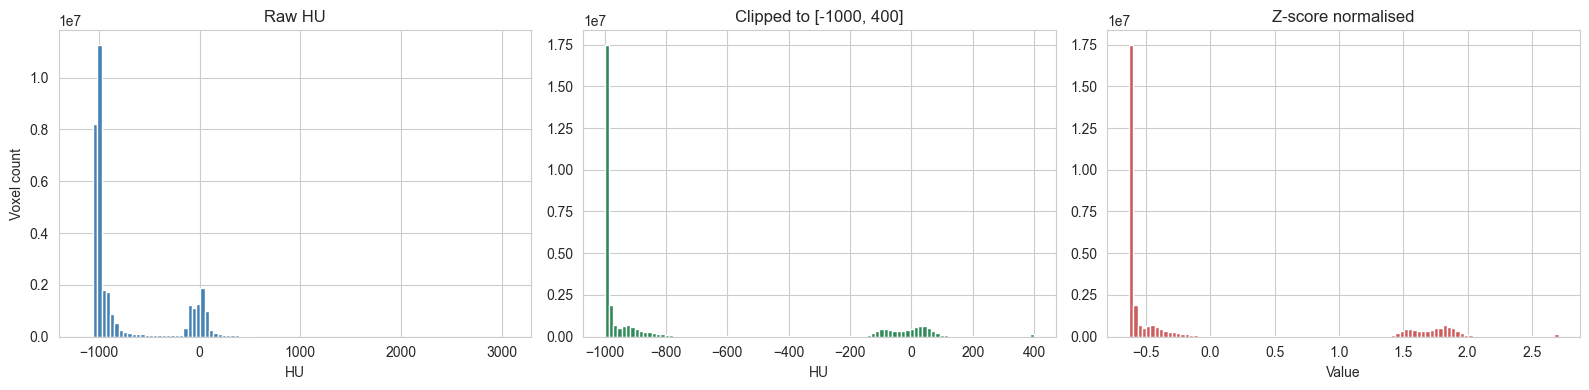

Raw HU range:        [-1185.0, 3076.0]
Clipped HU range:    [-1000.0, 400.0]
Normalised mean:     0.000001
Normalised std:      1.000000


In [5]:
HU_MIN, HU_MAX = -1000, 400

raw_values = ct_resampled_array.ravel().astype(np.float32)
clipped_values = np.clip(raw_values, HU_MIN, HU_MAX)
normalised_values = clip_and_normalise(ct_resampled_array, hu_min=HU_MIN, hu_max=HU_MAX).ravel()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(raw_values, bins=100, color="steelblue")
axes[0].set_title("Raw HU")
axes[0].set_xlabel("HU")
axes[0].set_ylabel("Voxel count")

axes[1].hist(clipped_values, bins=100, color="seagreen")
axes[1].set_title(f"Clipped to [{HU_MIN}, {HU_MAX}]")
axes[1].set_xlabel("HU")

axes[2].hist(normalised_values, bins=100, color="indianred")
axes[2].set_title("Z-score normalised")
axes[2].set_xlabel("Value")

plt.tight_layout()
plt.show()

print(f"Raw HU range:        [{raw_values.min():.1f}, {raw_values.max():.1f}]")
print(f"Clipped HU range:    [{clipped_values.min():.1f}, {clipped_values.max():.1f}]")
print(f"Normalised mean:     {normalised_values.mean():.6f}")
print(f"Normalised std:      {normalised_values.std():.6f}")

## Full pipeline on sanity sample

Run `preprocess_patient` end-to-end on the 8-patient sanity sample identified in the TCIA EDA, saving outputs to `data/processed/radiomics/`.

In [6]:
SANITY_PATIENTS = [
    "LUNG1-001", "LUNG1-013", "LUNG1-303", "LUNG1-378",
    "LUNG1-328", "LUNG1-380", "LUNG1-048", "LUNG1-280",
]

metadata_records = []
for pid in tqdm(SANITY_PATIENTS, desc="Preprocessing sanity sample"):
    meta = preprocess_patient(
        patient_id=pid,
        raw_dir=RAW_DIR,
        output_dir=PROCESSED_DIR,
        target_spacing=TARGET_SPACING,
    )
    metadata_records.append(meta)

metadata_df = pd.DataFrame(metadata_records)
display(metadata_df)

Preprocessing sanity sample:   0%|          | 0/8 [00:00<?, ?it/s]

,patient_id,original_spacing,original_shape,target_spacing,resampled_shape,hu_min,hu_max,mean_hu_before_clip,mean_after_normalise,std_after_normalise,mask_voxel_count_original,mask_voxel_count_resampled
0,LUNG1-001,"[0.9765625, 0.9765625, 3.0]","[134, 512, 512]","[1.0, 1.0, 3.0]","[134, 500, 500]",-1000.0,400.0,-741.027588,6.899305e-07,1.000000,56637,53789
1,LUNG1-013,"[0.9765625, 0.9765625, 3.0]","[134, 512, 512]","[1.0, 1.0, 3.0]","[134, 500, 500]",-1000.0,400.0,-701.669434,4.508585e-07,1.000000,5422,5019
2,LUNG1-303,"[0.9765625, 0.9765625, 3.0]","[134, 512, 512]","[1.0, 1.0, 3.0]","[134, 500, 500]",-1000.0,400.0,-796.790405,-2.030587e-06,0.999999,55116,52784
3,LUNG1-378,"[0.9765625, 0.9765625, 3.0]","[134, 512, 512]","[1.0, 1.0, 3.0]","[134, 500, 500]",-1000.0,400.0,-755.814453,-4.833656e-07,1.000000,6065,5786
4,LUNG1-328,"[0.9765625, 0.9765625, 3.0]","[132, 512, 512]","[1.0, 1.0, 3.0]","[132, 500, 500]",-1000.0,400.0,-777.512634,2.423192e-06,1.000001,1155,1094
5,LUNG1-380,"[0.9765625, 0.9765625, 3.0]","[131, 512, 512]","[1.0, 1.0, 3.0]","[131, 500, 500]",-1000.0,400.0,-806.223083,3.088763e-06,1.000000,6679,6406
6,LUNG1-048,"[0.9765625, 0.9765625, 3.0]","[135, 512, 512]","[1.0, 1.0, 3.0]","[135, 500, 500]",-1000.0,400.0,-811.404358,6.001374e-06,1.000001,18874,18038
7,LUNG1-280,"[0.9765625, 0.9765625, 3.0]","[130, 512, 512]","[1.0, 1.0, 3.0]","[130, 500, 500]",-1000.0,400.0,-715.199097,-1.199283e-06,1.000000,27301,25827


In [7]:
voxel_vol_cm3 = np.prod(TARGET_SPACING) / 1000.0

summary_rows = []
for pid in SANITY_PATIENTS:
    ct = np.load(PROCESSED_DIR / f"{pid}_ct.npy")
    mask = np.load(PROCESSED_DIR / f"{pid}_mask.npy")

    assert ct.shape == mask.shape, f"{pid}: CT/mask shape mismatch {ct.shape} vs {mask.shape}"
    assert set(np.unique(mask).tolist()) <= {0, 1}, f"{pid}: mask is not binary"
    assert mask.sum() > 0, f"{pid}: mask has no foreground voxels"

    summary_rows.append({
        "patient_id": pid,
        "ct_shape": ct.shape,
        "mask_shape": mask.shape,
        "ct_mean": ct.mean(),
        "ct_std": ct.std(),
        "mask_voxels": int(mask.sum()),
        "tumour_cm3": mask.sum() * voxel_vol_cm3,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("All checks passed: CT/mask shapes match, masks are binary, "
      "CT volumes are ~zero-mean/unit-std, and all masks have foreground voxels.")

,patient_id,ct_shape,mask_shape,ct_mean,ct_std,mask_voxels,tumour_cm3
0,LUNG1-001,"(134, 500, 500)","(134, 500, 500)",6.899305e-07,1.000000,53789,161.367
1,LUNG1-013,"(134, 500, 500)","(134, 500, 500)",4.508585e-07,1.000000,5019,15.057
2,LUNG1-303,"(134, 500, 500)","(134, 500, 500)",-2.030587e-06,0.999999,52784,158.352
3,LUNG1-378,"(134, 500, 500)","(134, 500, 500)",-4.833656e-07,1.000000,5786,17.358
4,LUNG1-328,"(132, 500, 500)","(132, 500, 500)",2.423192e-06,1.000001,1094,3.282
5,LUNG1-380,"(131, 500, 500)","(131, 500, 500)",3.088763e-06,1.000000,6406,19.218
6,LUNG1-048,"(135, 500, 500)","(135, 500, 500)",6.001374e-06,1.000001,18038,54.114
7,LUNG1-280,"(130, 500, 500)","(130, 500, 500)",-1.199283e-06,1.000000,25827,77.481


All checks passed: CT/mask shapes match, masks are binary, CT volumes are ~zero-mean/unit-std, and all masks have foreground voxels.


## Summary

### Preprocessing decisions and rationale

| Decision | Value | Rationale |
|---|---|---|
| Target spacing | (1.0, 1.0, 3.0) mm | Native NSCLC-Radiomics spacing is ~0.977 x 0.977 x 3.0 mm. Rounding the in-plane spacing to 1.0 mm gives a clean grid (512x512 -> 500x500) with minimal interpolation, while z spacing is left unchanged since 3.0 mm is already the native slice thickness for the cohort. |
| CT interpolation | B-spline | Smooth intensity interpolation, standard for resampling CT intensity volumes. |
| Mask interpolation | Nearest-neighbour | Preserves binary (0/1) labels — confirmed `np.unique(mask_resampled) == [0, 1]` after resampling. |
| HU window | [-1000, 400] | Covers air/lung parenchyma through soft tissue and bone (tumour + surrounding anatomy), discards extreme outliers (raw range reached +3076 HU). |
| Normalisation | Per-volume z-score, after clipping | Standardises intensity statistics across patients/scanners. Confirmed mean ~0, std ~1 for every sanity-sample patient. |
| Patch size | (128, 128, 64) — recorded, not implemented here | Reserved for future training/inference tiling. |

### Sanity sample (8 patients)

| Patient | CT shape (Z,Y,X) | Mask shape | CT mean | CT std | Mask voxels | Tumour volume (cm³) |
|---|---|---|---|---|---|---|
| LUNG1-001 | (134, 500, 500) | (134, 500, 500) | ~6.9e-7 | 1.0000 | 53,789 | 161.37 |
| LUNG1-013 | (134, 500, 500) | (134, 500, 500) | ~4.5e-7 | 1.0000 | 5,019 | 15.06 |
| LUNG1-303 | (134, 500, 500) | (134, 500, 500) | ~-2.0e-6 | 1.0000 | 52,784 | 158.35 |
| LUNG1-378 | (134, 500, 500) | (134, 500, 500) | ~-4.8e-7 | 1.0000 | 5,786 | 17.36 |
| LUNG1-328 | (132, 500, 500) | (132, 500, 500) | ~2.4e-6 | 1.0000 | 1,094 | 3.28 |
| LUNG1-380 | (131, 500, 500) | (131, 500, 500) | ~3.1e-6 | 1.0000 | 6,406 | 19.22 |
| LUNG1-048 | (135, 500, 500) | (135, 500, 500) | ~6.0e-6 | 1.0000 | 18,038 | 54.11 |
| LUNG1-280 | (130, 500, 500) | (130, 500, 500) | ~-1.2e-6 | 1.0000 | 25,827 | 77.48 |

All 8 patients passed every check: CT/mask shapes match, masks are strictly binary `{0, 1}`, CT volumes are zero-mean/unit-std, and every mask has foreground voxels. 24 files were written to `data/processed/radiomics/` (`<id>_ct.npy`, `<id>_mask.npy`, `<id>_meta.json` per patient).

